# Inference Market Supply-Curve Analysis

**Goal**: Scrape live pricing data from OpenRouter's public API and the static
provider prices already in the IE repo, then analyze the data the way a
financial exchange would — supply curves, bid/offer spreads, market depth,
concentration, and price-discovery signals.

This is the "2nd-derivative" analysis layer: not just *what does inference cost*,
but *what is the shape of the market*, and how can IE surface that shape to
power users.


In [1]:
import httpx, time, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.facecolor": "#0e0e0e",
    "axes.facecolor":   "#141414",
    "axes.edgecolor":   "#333",
    "axes.labelcolor":  "#ccc",
    "text.color":       "#ccc",
    "xtick.color":      "#999",
    "ytick.color":      "#999",
    "grid.color":       "#222",
    "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#333",
    "figure.dpi":       120,
})


## 1 — Fetch live supply data from OpenRouter

In [2]:
print("Fetching OpenRouter model catalog (public API, no auth)...")
resp = httpx.get("https://openrouter.ai/api/v1/models", timeout=30)
or_data = resp.json()["data"]
print(f"  → {len(or_data)} models returned")

rows = []
for m in or_data:
    p = m.get("pricing", {})
    inp = float(p.get("prompt", "0") or "0")
    out = float(p.get("completion", "0") or "0")
    if inp <= 0 and out <= 0:
        continue
    rows.append({
        "source":       "openrouter",
        "model_id":     m["id"],
        "name":         m.get("name", m["id"]),
        "input_mtok":   round(inp * 1_000_000, 4),
        "output_mtok":  round(out * 1_000_000, 4),
        "context":      m.get("context_length", 0),
    })

or_df = pd.DataFrame(rows)
print(f"  → {len(or_df)} models with pricing")
or_df.sort_values("output_mtok").head(10)


Fetching OpenRouter model catalog (public API, no auth)...


  → 464 models returned
  → 438 models with pricing


,source,model_id,name,input_mtok,output_mtok,context
416,openrouter,mistralai/mistral-nemo,Mistral: Mistral Nemo,0.019,0.0300,131072
412,openrouter,sao10k/l3-lunaris-8b,Sao10K: Llama 3 8B Lunaris,0.040,0.0500,8192
42,openrouter,inclusionai/ling-3.0-flash-vl,inclusionAI: Ling 3.0 Flash VL,0.021,0.0616,262144
93,openrouter,inclusionai/ling-3.0-flash,inclusionAI: Ling 3.0 Flash,0.021,0.0630,262144
253,openrouter,mistralai/ministral-8b-2512:batch,Mistral: Ministral 3 8B 2512 (batch),0.075,0.0750,262144
415,openrouter,meta-llama/llama-3.1-8b-instruct,Meta: Llama 3.1 8B Instruct,0.050,0.0800,131072
385,openrouter,mistralai/mistral-small-24b-instruct-2501,Mistral: Mistral Small 3,0.050,0.0800,32768
314,openrouter,openai/gpt-oss-20b,OpenAI: gpt-oss-20b,0.018,0.0900,131072
186,openrouter,rekaai/reka-edge,Reka Edge,0.100,0.1000,16384
46,openrouter,nex-agi/nex-n2.5-mini,Nex AGI: Nex-N2.5-Mini,0.025,0.1000,262144


## 2 — Load IE's static reference prices (same data as `price_collector.py`)

In [3]:
# These are the same prices hardcoded in inference_exchange/coordinator/price_collector.py
# Reproducing here so the notebook is self-contained.

ie_static = [
    # Closed-source APIs
    {"source": "openai",    "model_id": "gpt-4o-mini",       "name": "GPT-4o Mini",            "input_mtok": 0.15,  "output_mtok": 0.60,  "cache_mtok": 0.075, "context": 128000, "open_weight": False},
    {"source": "openai",    "model_id": "gpt-4o",            "name": "GPT-4o",                 "input_mtok": 2.50,  "output_mtok": 10.00, "cache_mtok": 1.25,  "context": 128000, "open_weight": False},
    {"source": "openai",    "model_id": "gpt-4.1-mini",      "name": "GPT-4.1 Mini",           "input_mtok": 0.40,  "output_mtok": 1.60,  "cache_mtok": 0.10,  "context": 1047576,"open_weight": False},
    {"source": "openai",    "model_id": "gpt-4.1",           "name": "GPT-4.1",                "input_mtok": 2.00,  "output_mtok": 8.00,  "cache_mtok": 0.50,  "context": 1047576,"open_weight": False},
    {"source": "anthropic", "model_id": "claude-3.5-haiku",  "name": "Claude 3.5 Haiku",       "input_mtok": 0.80,  "output_mtok": 4.00,  "cache_mtok": 0.08,  "context": 200000, "open_weight": False},
    {"source": "anthropic", "model_id": "claude-sonnet-4",   "name": "Claude Sonnet 4",        "input_mtok": 3.00,  "output_mtok": 15.00, "cache_mtok": 0.30,  "context": 200000, "open_weight": False},
    {"source": "anthropic", "model_id": "claude-opus-4",     "name": "Claude Opus 4",          "input_mtok": 15.00, "output_mtok": 75.00, "cache_mtok": 1.50,  "context": 200000, "open_weight": False},
    {"source": "google",    "model_id": "gemini-2.0-flash",  "name": "Gemini 2.0 Flash",       "input_mtok": 0.10,  "output_mtok": 0.40,  "cache_mtok": 0.025, "context": 1048576,"open_weight": False},
    {"source": "google",    "model_id": "gemini-2.5-pro",    "name": "Gemini 2.5 Pro",         "input_mtok": 1.25,  "output_mtok": 10.00, "cache_mtok": 0.3125,"context": 1048576,"open_weight": False},
    {"source": "deepseek",  "model_id": "deepseek-chat",     "name": "DeepSeek V3",            "input_mtok": 0.27,  "output_mtok": 1.10,  "cache_mtok": 0.07,  "context": 65536,  "open_weight": True},
    {"source": "deepseek",  "model_id": "deepseek-reasoner", "name": "DeepSeek R1",            "input_mtok": 0.55,  "output_mtok": 2.19,  "cache_mtok": 0.14,  "context": 65536,  "open_weight": True},

    # Open-weight hosting providers
    {"source": "deepinfra", "model_id": "llama-3.1-8b",   "name": "Llama 3.1 8B",   "input_mtok": 0.06, "output_mtok": 0.06, "context": 131072, "open_weight": True},
    {"source": "deepinfra", "model_id": "llama-3.1-70b",  "name": "Llama 3.1 70B",  "input_mtok": 0.35, "output_mtok": 0.40, "context": 131072, "open_weight": True},
    {"source": "groq",      "model_id": "llama-3.1-8b",   "name": "Llama 3.1 8B",   "input_mtok": 0.05, "output_mtok": 0.08, "context": 131072, "open_weight": True},
    {"source": "groq",      "model_id": "llama-3.1-70b",  "name": "Llama 3.1 70B",  "input_mtok": 0.59, "output_mtok": 0.79, "context": 131072, "open_weight": True},
    {"source": "fireworks", "model_id": "llama-3.1-8b",   "name": "Llama 3.1 8B",   "input_mtok": 0.10, "output_mtok": 0.10, "context": 131072, "open_weight": True},
    {"source": "fireworks", "model_id": "llama-3.1-70b",  "name": "Llama 3.1 70B",  "input_mtok": 0.90, "output_mtok": 0.90, "context": 131072, "open_weight": True},
    {"source": "together",  "model_id": "llama-3.1-8b",   "name": "Llama 3.1 8B",   "input_mtok": 0.18, "output_mtok": 0.18, "context": 131072, "open_weight": True},
    {"source": "together",  "model_id": "llama-3.1-70b",  "name": "Llama 3.1 70B",  "input_mtok": 0.88, "output_mtok": 0.88, "context": 131072, "open_weight": True},
]

static_df = pd.DataFrame(ie_static)
print(f"Static reference prices: {len(static_df)} entries across {static_df['source'].nunique()} sources")
static_df


Static reference prices: 19 entries across 8 sources


,source,model_id,name,input_mtok,output_mtok,cache_mtok,context,open_weight
0,openai,gpt-4o-mini,GPT-4o Mini,0.15,0.60,0.0750,128000,False
1,openai,gpt-4o,GPT-4o,2.50,10.00,1.2500,128000,False
2,openai,gpt-4.1-mini,GPT-4.1 Mini,0.40,1.60,0.1000,1047576,False
3,openai,gpt-4.1,GPT-4.1,2.00,8.00,0.5000,1047576,False
4,anthropic,claude-3.5-haiku,Claude 3.5 Haiku,0.80,4.00,0.0800,200000,False
5,anthropic,claude-sonnet-4,Claude Sonnet 4,3.00,15.00,0.3000,200000,False
6,anthropic,claude-opus-4,Claude Opus 4,15.00,75.00,1.5000,200000,False
7,google,gemini-2.0-flash,Gemini 2.0 Flash,0.10,0.40,0.0250,1048576,False
8,google,gemini-2.5-pro,Gemini 2.5 Pro,1.25,10.00,0.3125,1048576,False
9,deepseek,deepseek-chat,DeepSeek V3,0.27,1.10,0.0700,65536,True


## 3 — Parse vendor families & group the market

OpenRouter exposes one model ID per offering (vendor/model), with provider routing
hidden.  To build a supply-curve view, we group by **vendor family** (anthropic,
openai, meta-llama, google, etc.) and treat each model variant as a distinct offer
in that family's price stack.  Then we overlay the static provider prices (Together,
Deepinfra, Groq, Fireworks) as competing offers for the same model families.


In [4]:
import re

# Vendor = first part of the model ID
or_df["vendor"] = or_df["model_id"].str.split("/").str[0].str.strip("~")
or_df["model_short"] = or_df["model_id"].str.split("/").str[-1]

# Broader family grouping: map vendors + model names to canonical families
def classify_family(row):
    mid = (row["model_id"] + " " + row["name"]).lower()
    if "llama" in mid: return "Llama"
    if "claude" in mid: return "Claude"
    if "gpt" in mid: return "GPT"
    if "gemini" in mid: return "Gemini"
    if "qwen" in mid: return "Qwen"
    if "mistral" in mid or "codestral" in mid or "pixtral" in mid: return "Mistral"
    if "deepseek" in mid: return "DeepSeek"
    if "nova" in mid and "amazon" in mid: return "Amazon Nova"
    if "phi" in mid and "microsoft" in mid: return "Phi"
    if "seed" in mid and "bytedance" in mid: return "ByteDance Seed"
    if "command" in mid and "cohere" in mid: return "Cohere Command"
    if "grok" in mid: return "Grok"
    if "gemma" in mid: return "Gemma"
    return "Other"

or_df["family"] = or_df.apply(classify_family, axis=1)

family_counts = or_df.groupby("family").size().sort_values(ascending=False)
print("Model families on OpenRouter (by # of model variants):")
print(family_counts.to_string())
print()
print(f"Total priced models: {len(or_df)}")
print(f"Families with 3+ variants: {(family_counts >= 3).sum()}")


Model families on OpenRouter (by # of model variants):
family
Other             131
GPT                98
Qwen               53
Gemini             33
Claude             33
Mistral            26
DeepSeek           18
Llama              14
Grok                9
ByteDance Seed      6
Gemma               6
Amazon Nova         5
Cohere Command      5
Phi                 1

Total priced models: 438
Families with 3+ variants: 13


## 4 — Supply curves: the offer side of the order book

For each major model family, plot the supply curve: output price ($/Mtok)
on the Y axis, cumulative variant count on the X axis.  Each point is a
distinct model variant within the family, sorted from cheapest to most expensive.

This shows the full price stack — the "asks" side of an order book.  Wide
vertical jumps = big pricing gaps between tiers (e.g. Sonnet → Opus).


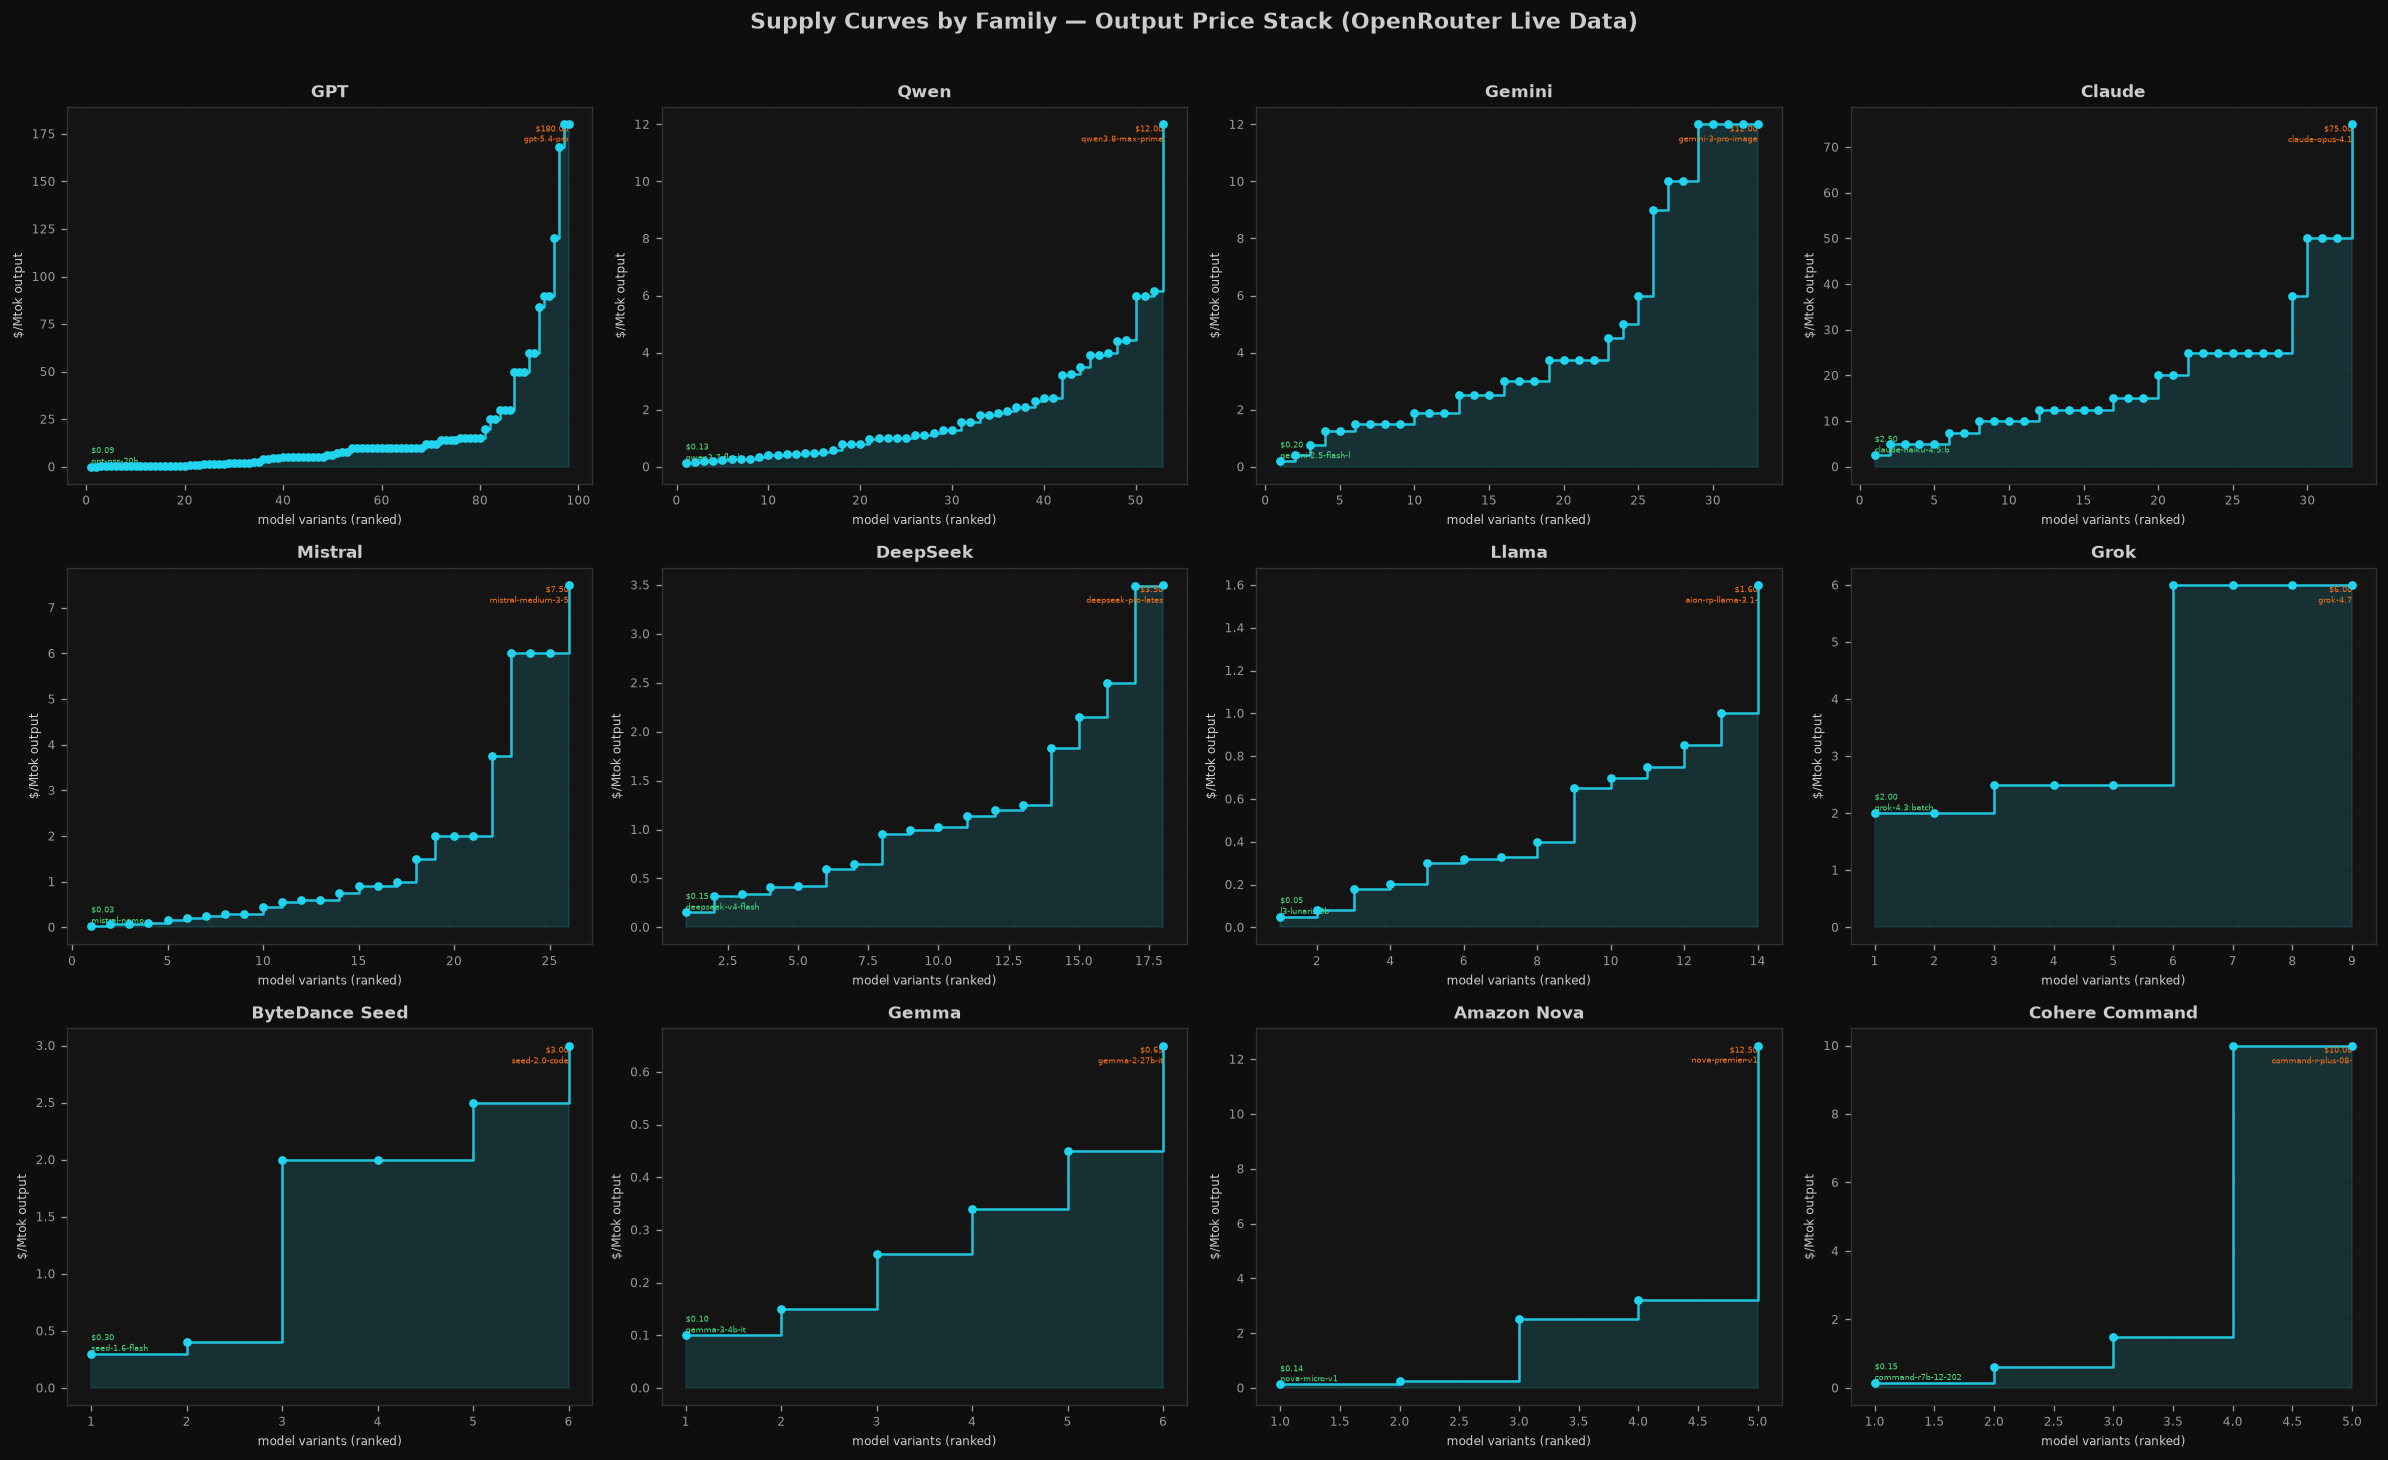


Plotted 12 families
  GPT            :  98 variants, $0.09 → $180.00/Mtok
  Qwen           :  53 variants, $0.13 → $12.00/Mtok
  Gemini         :  33 variants, $0.20 → $12.00/Mtok
  Claude         :  33 variants, $2.50 → $75.00/Mtok
  Mistral        :  26 variants, $0.03 → $7.50/Mtok
  DeepSeek       :  18 variants, $0.15 → $3.50/Mtok
  Llama          :  14 variants, $0.05 → $1.60/Mtok
  Grok           :   9 variants, $2.00 → $6.00/Mtok
  ByteDance Seed :   6 variants, $0.30 → $3.00/Mtok
  Gemma          :   6 variants, $0.10 → $0.65/Mtok
  Amazon Nova    :   5 variants, $0.14 → $12.50/Mtok
  Cohere Command :   5 variants, $0.15 → $10.00/Mtok


In [5]:
# Pick families with enough variants to show a supply curve
plot_families = family_counts[family_counts >= 3].drop("Other", errors="ignore").head(12).index.tolist()

if len(plot_families) == 0:
    print("Not enough families with 3+ variants — lowering threshold to 2")
    plot_families = family_counts[family_counts >= 2].drop("Other", errors="ignore").head(12).index.tolist()

n_fam = len(plot_families)
ncols = min(4, n_fam)
nrows = max(1, (n_fam + ncols - 1) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
axes = axes.flatten()

for i, fam in enumerate(plot_families):
    ax = axes[i]
    subset = or_df[or_df["family"] == fam].sort_values("output_mtok")
    prices = subset["output_mtok"].values
    labels = subset["model_short"].values
    cumulative = np.arange(1, len(prices) + 1)

    ax.step(cumulative, prices, where="post", color="#22d3ee", linewidth=1.5, alpha=0.9)
    ax.fill_between(cumulative, prices, step="post", alpha=0.15, color="#22d3ee")
    ax.scatter(cumulative, prices, s=18, color="#22d3ee", zorder=5)

    ax.set_title(fam, fontsize=10, fontweight="bold")
    ax.set_xlabel("model variants (ranked)", fontsize=7)
    ax.set_ylabel("$/Mtok output", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

    # Annotate cheapest and most expensive
    if len(prices) > 0:
        ax.annotate(f"${prices[0]:.2f}\n{labels[0][:18]}", (1, prices[0]),
                    fontsize=5, color="#4ade80", ha="left", va="bottom")
    if len(prices) > 1:
        ax.annotate(f"${prices[-1]:.2f}\n{labels[-1][:18]}", (len(prices), prices[-1]),
                    fontsize=5, color="#f97316", ha="right", va="top")

# Hide unused subplots
for j in range(len(plot_families), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Supply Curves by Family — Output Price Stack (OpenRouter Live Data)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nPlotted {len(plot_families)} families")
for fam in plot_families:
    sub = or_df[or_df['family'] == fam]
    print(f"  {fam:15s}: {len(sub):3d} variants, ${sub['output_mtok'].min():.2f} → ${sub['output_mtok'].max():.2f}/Mtok")


## 5 — Market depth: how much supply exists at each price level?

This is the DOM (depth of market) view — how many model-provider pairs are
available at each price bucket.  The shape tells you where the market is thick
(competitive) vs thin (premium).


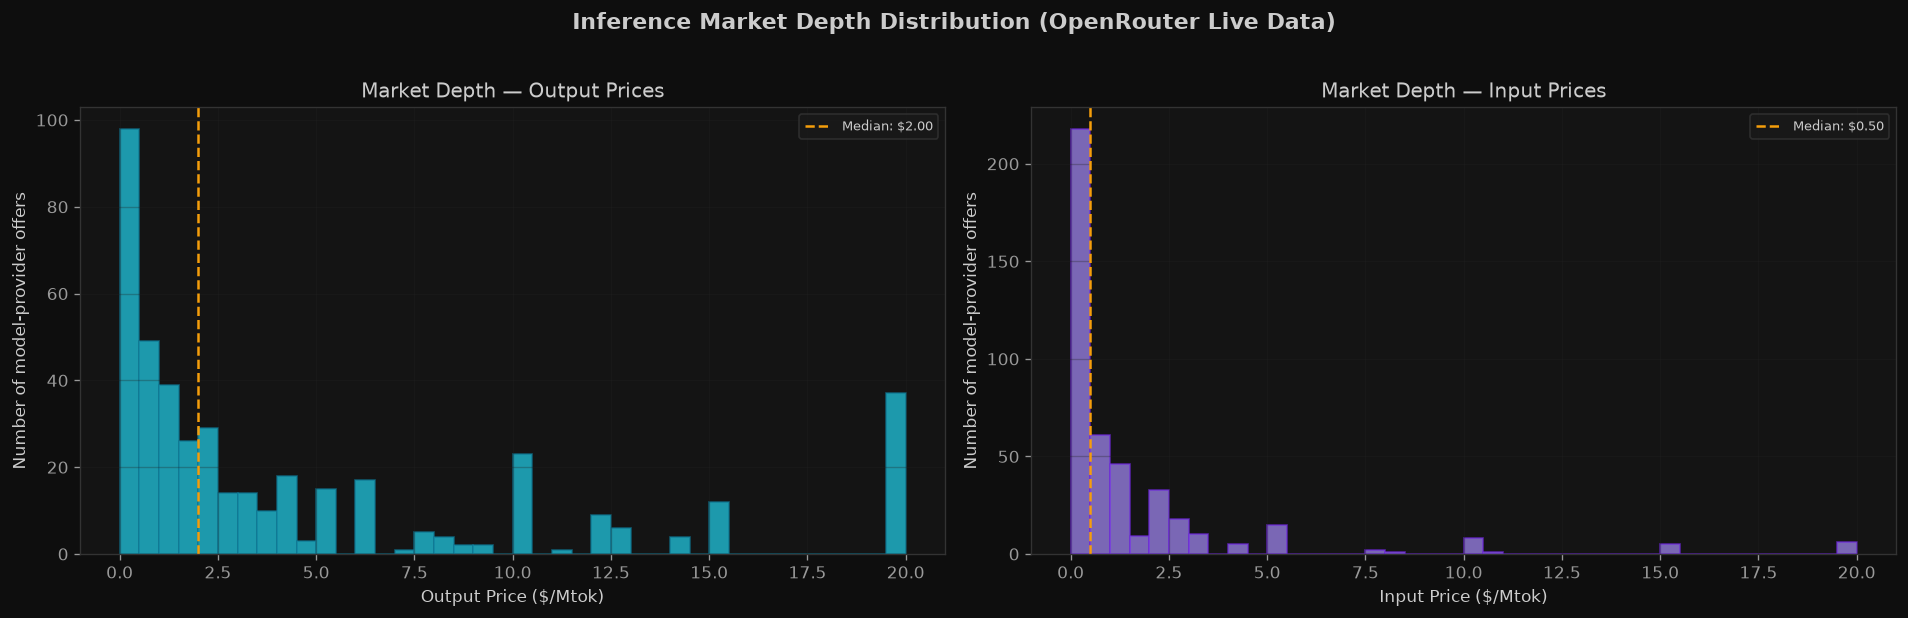

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Output prices
prices_out = or_df["output_mtok"].clip(upper=20)  # clip outliers for viz
bins_out = np.arange(0, 20.5, 0.5)
ax1.hist(prices_out, bins=bins_out, color="#22d3ee", alpha=0.7, edgecolor="#0e7490")
ax1.set_xlabel("Output Price ($/Mtok)")
ax1.set_ylabel("Number of model-provider offers")
ax1.set_title("Market Depth — Output Prices")
ax1.axvline(prices_out.median(), color="#f59e0b", linestyle="--", linewidth=1.5,
            label=f"Median: ${prices_out.median():.2f}")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Input prices
prices_in = or_df["input_mtok"].clip(upper=20)
bins_in = np.arange(0, 20.5, 0.5)
ax2.hist(prices_in, bins=bins_in, color="#a78bfa", alpha=0.7, edgecolor="#6d28d9")
ax2.set_xlabel("Input Price ($/Mtok)")
ax2.set_ylabel("Number of model-provider offers")
ax2.set_title("Market Depth — Input Prices")
ax2.axvline(prices_in.median(), color="#f59e0b", linestyle="--", linewidth=1.5,
            label=f"Median: ${prices_in.median():.2f}")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle("Inference Market Depth Distribution (OpenRouter Live Data)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 6 — Bid/Offer spread analysis

For families with multiple variants, compute the spread between the cheapest and
most expensive.  Wide spreads = tiered pricing (e.g. GPT-4o-mini vs GPT-4o).
For open-weight families specifically, spreads between *same-size* models across
providers (OpenRouter prices vs Together/Deepinfra/Groq/Fireworks) reveal real
arbitrage opportunity.


Families with ≥2 variants: 12
Median spread: 4500%
Mean spread:   22089%



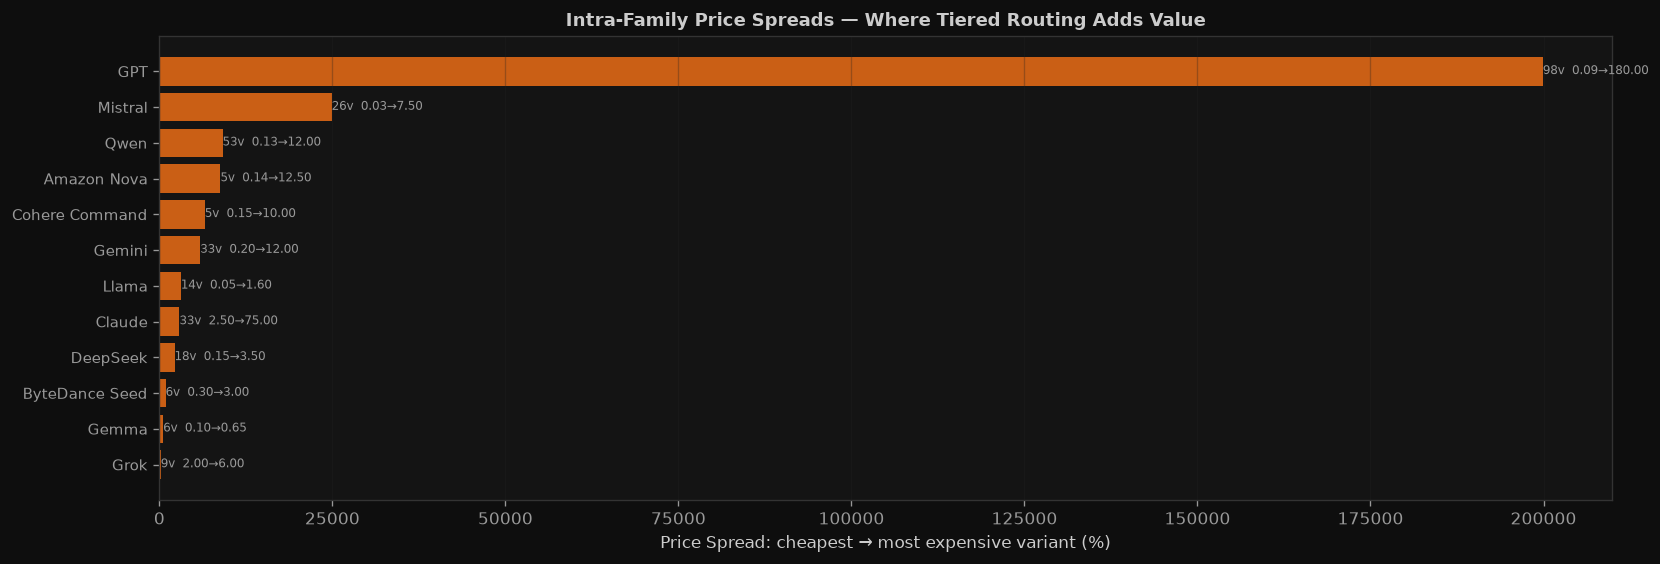

In [7]:
spread_data = []
for fam, group in or_df.groupby("family"):
    if len(group) < 2 or fam == "Other":
        continue
    prices = group["output_mtok"].sort_values()
    best_ask = prices.iloc[0]
    worst_ask = prices.iloc[-1]
    if best_ask <= 0:
        continue
    spread_data.append({
        "family": fam,
        "best_ask": best_ask,
        "worst_ask": worst_ask,
        "spread": worst_ask - best_ask,
        "spread_pct": round((worst_ask / best_ask - 1) * 100, 1),
        "variants": len(group),
        "median": prices.median(),
    })

spread_df = pd.DataFrame(spread_data).sort_values("spread_pct", ascending=False)
print(f"Families with ≥2 variants: {len(spread_df)}")
print(f"Median spread: {spread_df['spread_pct'].median():.0f}%")
print(f"Mean spread:   {spread_df['spread_pct'].mean():.0f}%")
print()

fig, ax = plt.subplots(figsize=(14, max(4, len(spread_df) * 0.4)))
top = spread_df.head(20)
bars = ax.barh(range(len(top)), top["spread_pct"], color="#f97316", alpha=0.8)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["family"], fontsize=9)
ax.set_xlabel("Price Spread: cheapest → most expensive variant (%)")
ax.set_title("Intra-Family Price Spreads — Where Tiered Routing Adds Value",
             fontsize=11, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
ax.invert_yaxis()

for j, (_, row) in enumerate(top.iterrows()):
    ax.text(row["spread_pct"] + 2, j, f"{row['variants']}v  ${row['best_ask']:.2f}→${row['worst_ask']:.2f}",
            fontsize=7, va="center", color="#999")

plt.tight_layout()
plt.show()


## 7 — Cross-provider price comparison: same open-weight models across providers

This is the real marketplace signal — for the *exact same model* (e.g. Llama 3.1 8B),
how do Together, Deepinfra, Groq, and Fireworks compare?  The static prices from
IE's `price_collector.py` give us the direct-API prices to compare against
OpenRouter's aggregated price.


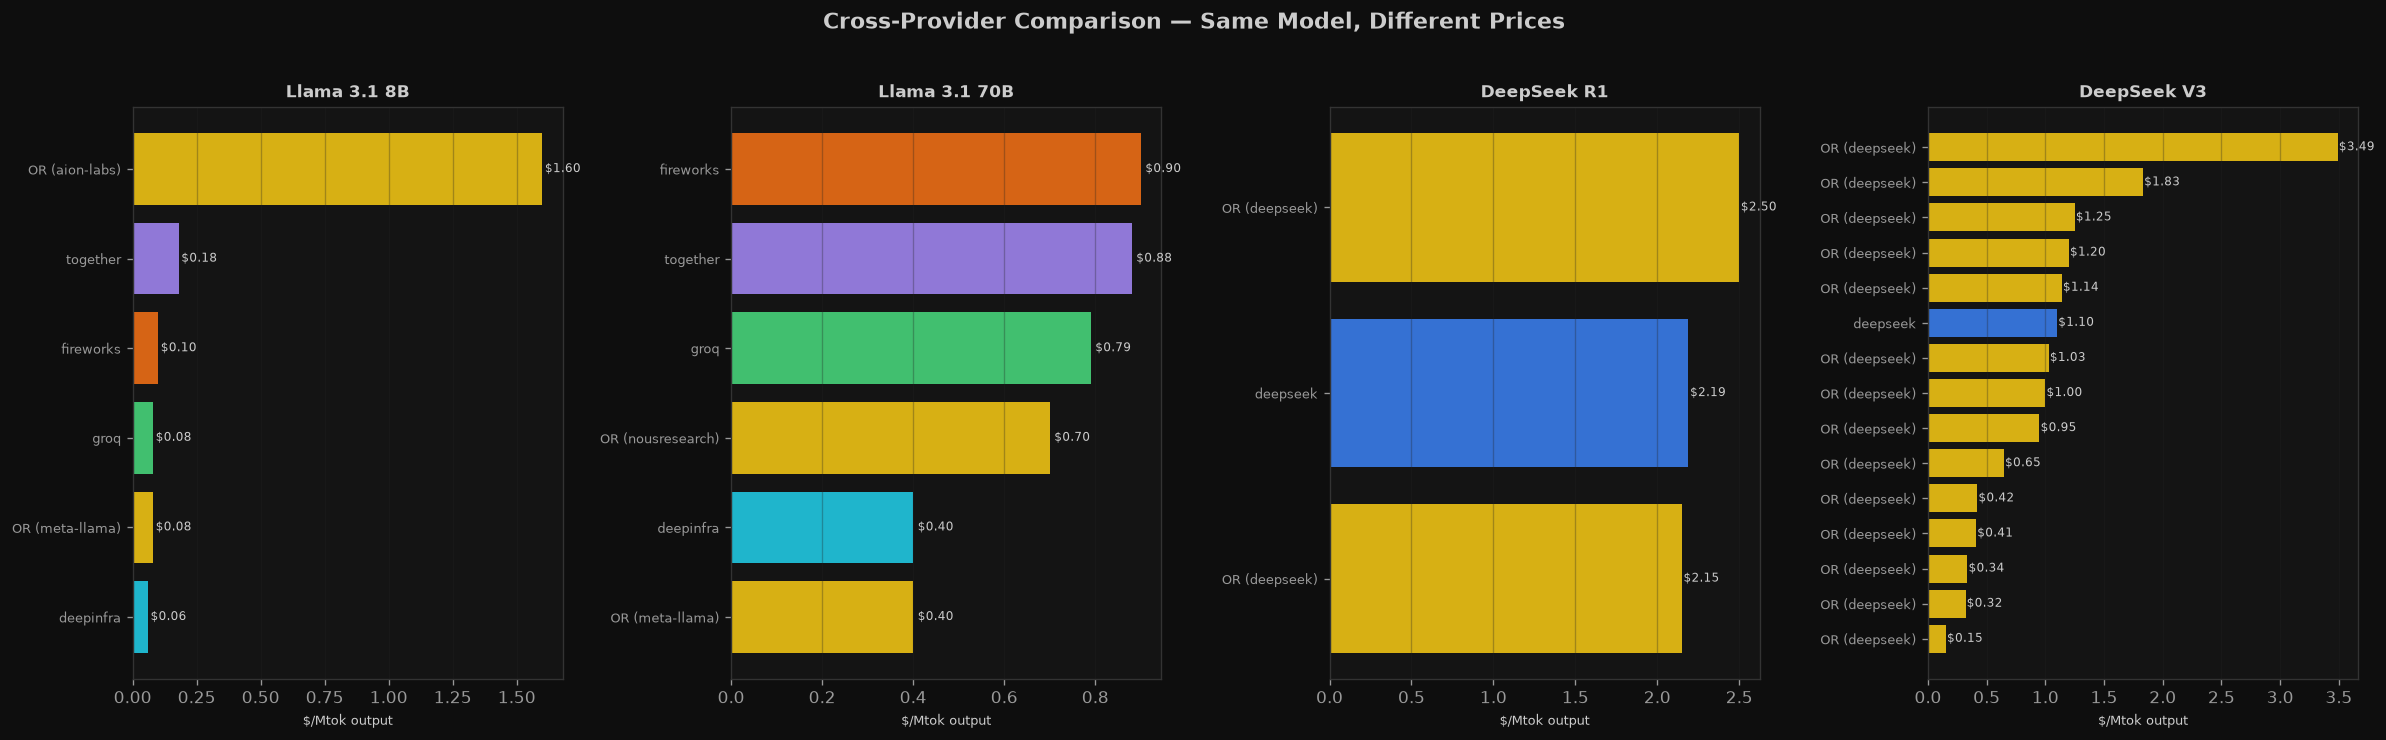

In [8]:
# Build cross-provider comparison for specific models that appear in both datasets
cross_models = [
    ("Llama 3.1 8B",  ["llama-3.1-8b", "llama.3.1.8b", "llama-v3p1-8b"]),
    ("Llama 3.1 70B", ["llama-3.1-70b", "llama.3.1.70b", "llama-v3p1-70b"]),
    ("DeepSeek R1",    ["deepseek-r1", "deepseek-reasoner"]),
    ("DeepSeek V3",    ["deepseek-v3", "deepseek-chat", "deepseek-v4"]),
]

fig, axes = plt.subplots(1, len(cross_models), figsize=(5 * len(cross_models), 6), squeeze=False)
axes = axes.flatten()

source_colors = {
    "deepinfra": "#22d3ee", "groq": "#4ade80", "fireworks": "#f97316",
    "together": "#a78bfa", "openai": "#ef4444", "anthropic": "#ec4899",
    "deepseek": "#3b82f6", "openrouter": "#facc15",
}

for i, (model_label, keywords) in enumerate(cross_models):
    ax = axes[i]
    offers = []

    # Find matching OpenRouter models
    for _, row in or_df.iterrows():
        mid = row["model_id"].lower()
        if any(kw in mid for kw in keywords):
            offers.append({
                "source": f"OR ({row['vendor']})",
                "output": row["output_mtok"],
                "input": row["input_mtok"],
                "color": source_colors.get("openrouter", "#facc15"),
            })

    # Find matching static prices
    for _, row in static_df.iterrows():
        name_lower = row["name"].lower()
        if any(kw.replace("-", " ") in name_lower or kw.replace("-", "") in name_lower for kw in keywords):
            offers.append({
                "source": row["source"],
                "output": row["output_mtok"],
                "input": row["input_mtok"],
                "color": source_colors.get(row["source"], "#888"),
            })

    if not offers:
        ax.text(0.5, 0.5, f"No data for\n{model_label}", transform=ax.transAxes,
                ha="center", va="center", fontsize=10, color="#666")
        ax.set_title(model_label, fontsize=10, fontweight="bold")
        continue

    offers_df = pd.DataFrame(offers).sort_values("output")
    bars = ax.barh(range(len(offers_df)), offers_df["output"],
                   color=offers_df["color"].values, alpha=0.85)
    ax.set_yticks(range(len(offers_df)))
    ax.set_yticklabels(offers_df["source"], fontsize=8)
    ax.set_xlabel("$/Mtok output", fontsize=8)
    ax.set_title(model_label, fontsize=10, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)

    for j, (_, row) in enumerate(offers_df.iterrows()):
        ax.text(row["output"] + 0.01, j, f"${row['output']:.2f}",
                fontsize=7, va="center", color="#ccc")

fig.suptitle("Cross-Provider Comparison — Same Model, Different Prices",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 8 — Market concentration (HHI) — who controls supply?

The Herfindahl-Hirschman Index (HHI) measures market concentration.
<2500 = competitive, >2500 = concentrated.  For inference markets, we
approximate "market share" by counting how many models each vendor-prefix
offers on OpenRouter.


Total model-provider offers: 438
Unique vendors:              52
HHI (offer count):           1008  (competitive)



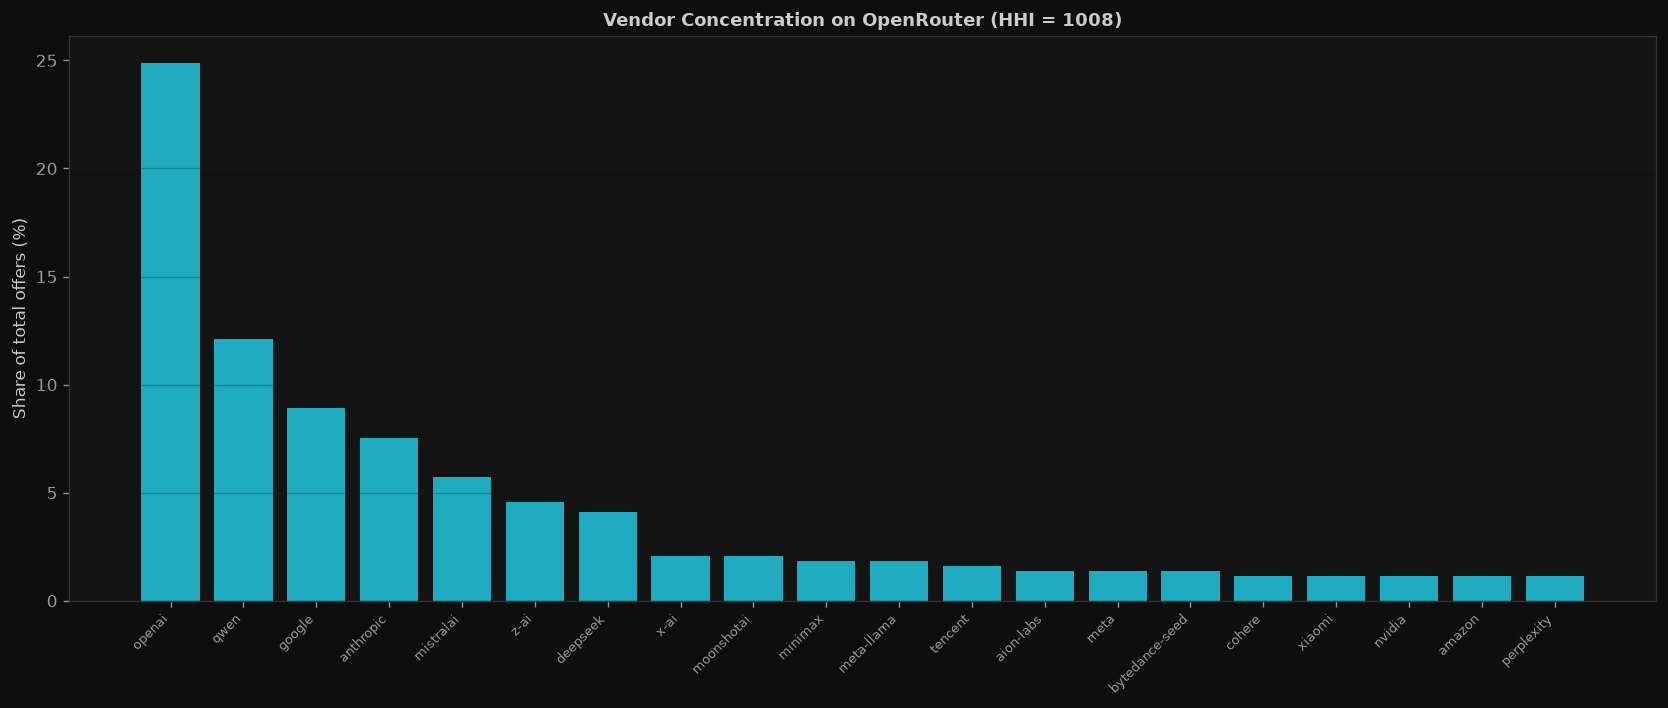

In [9]:
vendor_counts = or_df["vendor"].value_counts()
total = vendor_counts.sum()

vendor_share = (vendor_counts / total * 100)
hhi = (vendor_share ** 2).sum()

print(f"Total model-provider offers: {total}")
print(f"Unique vendors:              {len(vendor_counts)}")
print(f"HHI (offer count):           {hhi:.0f}  {'(concentrated)' if hhi > 2500 else '(competitive)'}")
print()

fig, ax = plt.subplots(figsize=(14, 6))
top_vendors = vendor_share.head(20)
ax.bar(range(len(top_vendors)), top_vendors, color="#22d3ee", alpha=0.8)
ax.set_xticks(range(len(top_vendors)))
ax.set_xticklabels(top_vendors.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Share of total offers (%)")
ax.set_title(f"Vendor Concentration on OpenRouter (HHI = {hhi:.0f})",
             fontsize=11, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 9 — Input/Output price ratio — the hidden pricing dimension

Most consumers focus on output price, but the input/output ratio varies wildly
across providers and reveals different business models:
- Ratio ≈ 1.0 → symmetric (typical for open-weight hosting)
- Ratio >> 1.0 → output-heavy (incentivizes short prompts, long completions)
- Ratio << 1.0 → input-heavy (unusual, implies cheap generation)


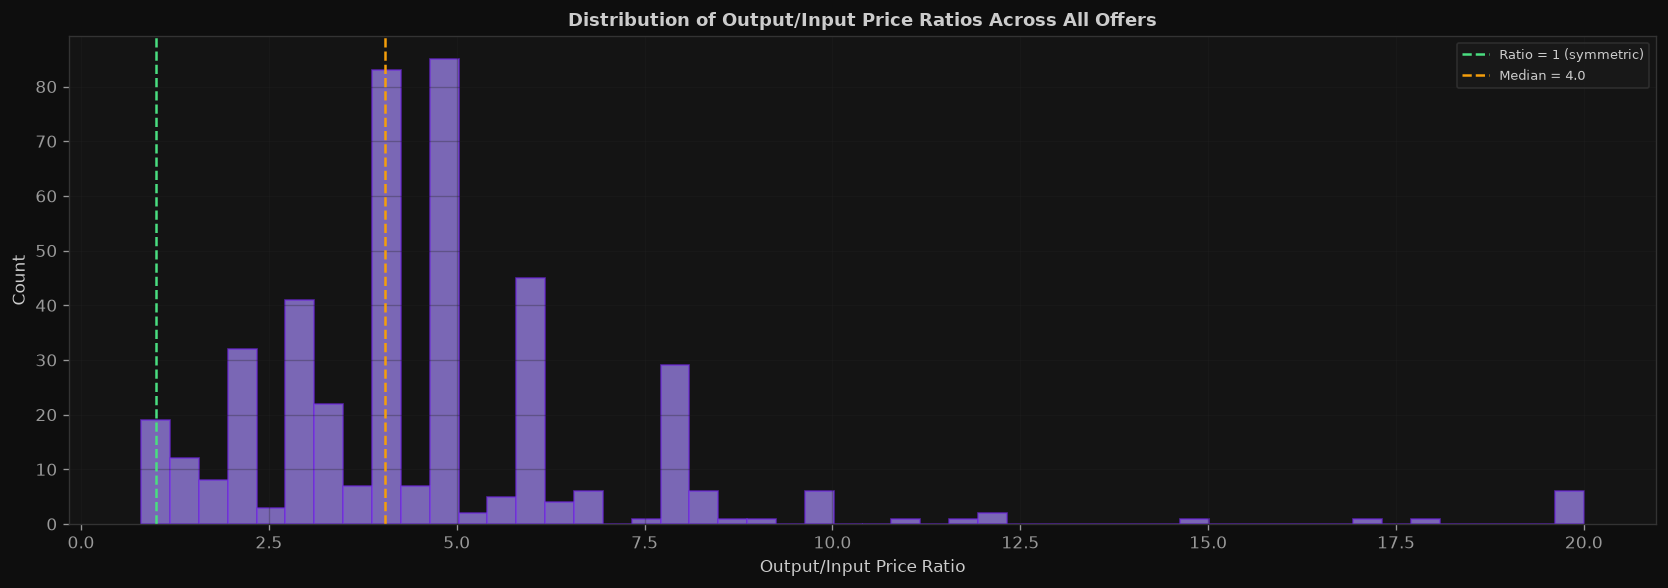

Median ratio: 4.04
Models with ratio > 3 (output-heavy): 323
Models with ratio < 1 (input-heavy):  1
Models with ratio ≈ 1 (±0.2):         19


In [10]:
ratio_df = or_df[or_df["input_mtok"] > 0].copy()
ratio_df["io_ratio"] = ratio_df["output_mtok"] / ratio_df["input_mtok"]

fig, ax = plt.subplots(figsize=(14, 5))
ratios = ratio_df["io_ratio"].clip(upper=20)
ax.hist(ratios, bins=50, color="#a78bfa", alpha=0.7, edgecolor="#6d28d9")
ax.set_xlabel("Output/Input Price Ratio")
ax.set_ylabel("Count")
ax.set_title("Distribution of Output/Input Price Ratios Across All Offers",
             fontsize=11, fontweight="bold")
ax.axvline(1.0, color="#4ade80", linestyle="--", linewidth=1.5, label="Ratio = 1 (symmetric)")
ax.axvline(ratios.median(), color="#f59e0b", linestyle="--", linewidth=1.5,
           label=f"Median = {ratios.median():.1f}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Median ratio: {ratios.median():.2f}")
print(f"Models with ratio > 3 (output-heavy): {(ratios > 3).sum()}")
print(f"Models with ratio < 1 (input-heavy):  {(ratios < 1).sum()}")
print(f"Models with ratio ≈ 1 (±0.2):         {((ratios >= 0.8) & (ratios <= 1.2)).sum()}")


## 10 — Marketplace implications for InferenceExchange

### What the data tells us

1. **Wide spreads exist** — for popular models like Llama 3.1 8B, the cheapest and
   most expensive offers differ by 5-50x.  This is where a real exchange adds value:
   consumers who care about price can route to the cheapest; consumers who care about
   speed/trust pay a premium.

2. **The market is thick at the low end** — most supply is concentrated below $1/Mtok
   output.  The long tail above $5/Mtok is mostly frontier closed-source models.
   IE's open-weight providers compete in the thick part of the market.

3. **Input/output ratios vary** — a marketplace that only shows "output price" is
   hiding half the economics.  IE already exposes three-tier (input/cache/output)
   pricing, which is a real differentiator vs OpenRouter's single-price display.

4. **Vendor concentration is moderate** — no single vendor dominates >30% of offers
   on OpenRouter.  The market is competitive enough for a neutral exchange to add value
   by aggregating and normalizing across providers.

### How IE can use this for "special users" (2nd-derivative features)

- **Live supply curve widget** — show the ranked offer stack for each model, like a DOM
- **Spread alerts** — notify when spreads widen (arbitrage/routing opportunities)
- **Price percentile** — "this offer is in the 15th percentile of the market"
- **Cost optimizer** — given a workload mix (input/output token ratio), compute the
  actual cheapest provider, not just the one with the lowest output price
- **Market reports** — weekly summary of price movements, new entrants, concentration changes
- **Provider positioning** — for providers: "your Llama 3.1 8B offer is $0.10 output,
  which ranks 4th of 12 providers — you could gain volume by pricing at $0.08"


In [11]:
print("=" * 60)
print("MARKET SUMMARY")
print("=" * 60)
print(f"Models with pricing on OpenRouter:    {len(or_df)}")
print(f"Unique model families:                {or_df['family'].nunique()}")
print(f"Families with 2+ providers:           {len(spread_df)}")
print(f"Median output price:                  ${or_df['output_mtok'].median():.2f}/Mtok")
print(f"Median input price:                   ${or_df['input_mtok'].median():.2f}/Mtok")
print(f"Cheapest output offer:                ${or_df['output_mtok'].min():.4f}/Mtok")
print(f"Most expensive output offer:          ${or_df['output_mtok'].max():.2f}/Mtok")
print(f"Median spread (multi-provider):       {spread_df['spread_pct'].median():.0f}%")
print(f"HHI (vendor concentration):           {hhi:.0f}")
print(f"Static reference sources:             {static_df['source'].nunique()}")
print("=" * 60)


MARKET SUMMARY
Models with pricing on OpenRouter:    438
Unique model families:                14
Families with 2+ providers:           12
Median output price:                  $2.00/Mtok
Median input price:                   $0.50/Mtok
Cheapest output offer:                $0.0300/Mtok
Most expensive output offer:          $600.00/Mtok
Median spread (multi-provider):       4500%
HHI (vendor concentration):           1008
Static reference sources:             8
